<a href="https://colab.research.google.com/github/alchemist-sourav/Netflix-Titles-Dataset-Analysis/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(df.head())

Saving netflix_titles.csv to netflix_titles.csv
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  T

In [6]:
import pandas as pd

file_path = "netflix_titles.csv"

df = pd.read_csv(file_path)

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [8]:
# First 5 rows
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics
print("\nSummary:")
print(df.describe(include='all'))

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [9]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

In [10]:
print(df['date_added'].head())

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [11]:
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna('Unknown')

In [12]:
print(df[['director', 'cast', 'country']].isnull().sum())

director    0
cast        0
country     0
dtype: int64


In [13]:
df['release_decade'] = (
    df['release_year'] // 10
) * 10

In [14]:
df['is_movie'] = (
    df['type'] == 'Movie'
).astype(int)

In [15]:
df['content_type'] = df['type']

In [16]:
df['added_year'] = df['date_added'].dt.year

In [17]:
print(
    df[
        [
            'release_year',
            'release_decade',
            'is_movie',
            'content_type',
            'added_year'
        ]
    ].head()
)

   release_year  release_decade  is_movie content_type  added_year
0          2020            2020         1        Movie      2021.0
1          2021            2020         0      TV Show      2021.0
2          2021            2020         0      TV Show      2021.0
3          2021            2020         0      TV Show      2021.0
4          2021            2020         0      TV Show      2021.0


In [18]:
all_countries = (
    df['country']
    .str.split(',')
    .explode()
    .str.strip()
)

top_5_countries = all_countries.value_counts().head(5)

print(top_5_countries)

country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
Name: count, dtype: int64


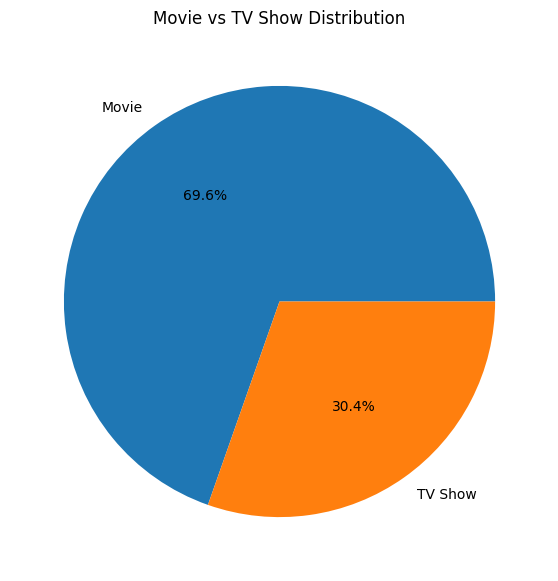

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movie vs TV Show Distribution')
plt.ylabel('')

plt.show()

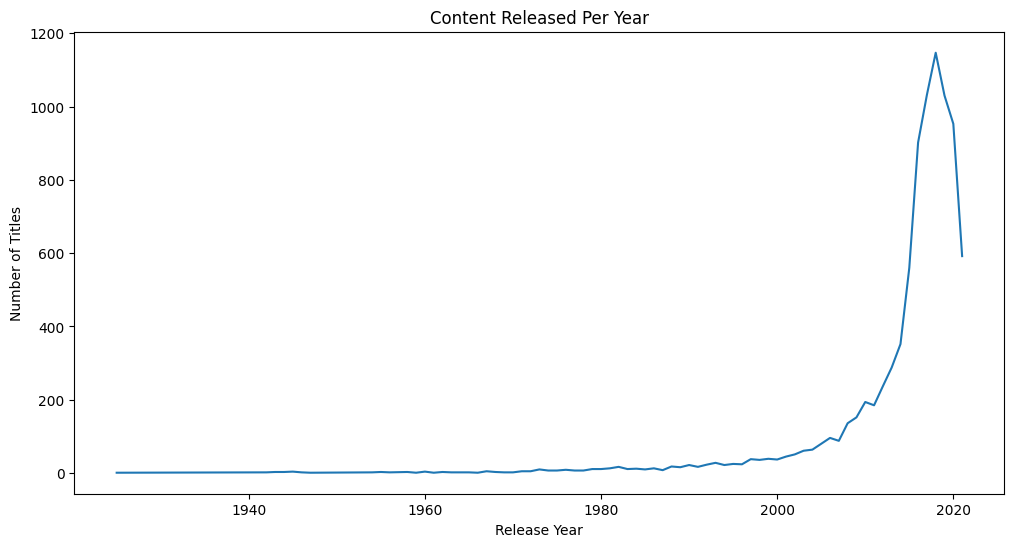

In [20]:
import seaborn as sns

yearly_content = (
    df.groupby('release_year')
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_content,
    x='release_year',
    y='count'
)

plt.title('Content Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

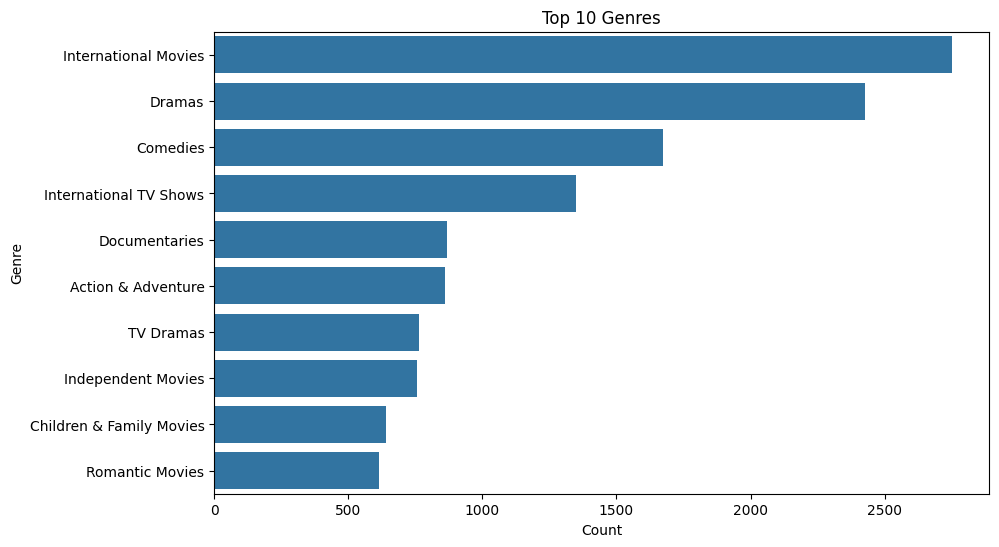

In [21]:
genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()

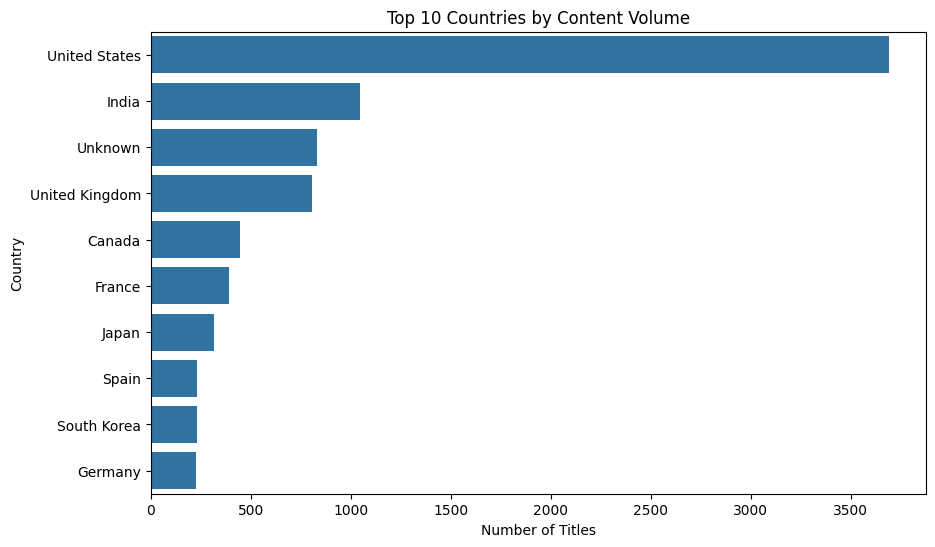

In [22]:
top_countries = (
    all_countries
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 Countries by Content Volume')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

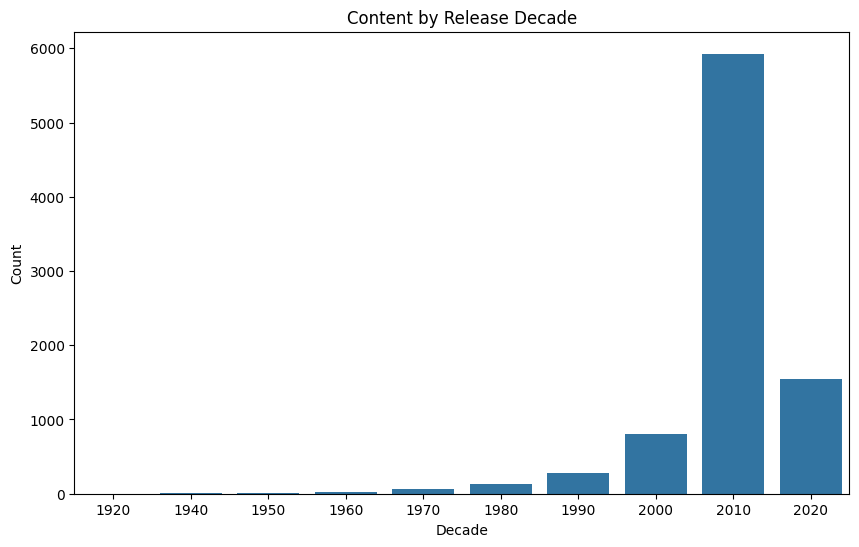

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='release_decade'
)

plt.title('Content by Release Decade')
plt.xlabel('Decade')
plt.ylabel('Count')

plt.show()

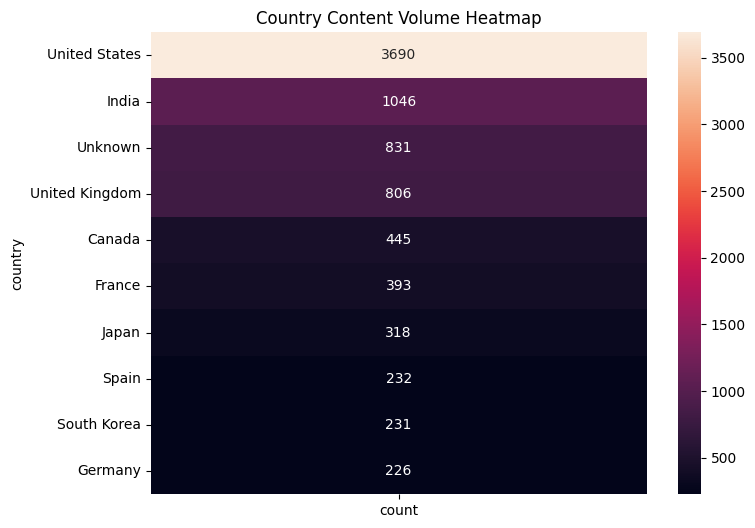

In [24]:
country_counts = (
    all_countries
    .value_counts()
    .head(10)
)

heatmap_df = pd.DataFrame(
    country_counts
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='g'
)

plt.title('Country Content Volume Heatmap')

plt.show()

In [25]:
print("========== NETFLIX DATASET INSIGHTS ==========\n")

print(
    "Movie Percentage:",
    round((df['type']=='Movie').mean()*100,2),
    "%"
)

print(
    "TV Show Percentage:",
    round((df['type']=='TV Show').mean()*100,2),
    "%"
)

print("\nTop Genre:")
print(top_genres.head(1))

print("\nTop Country:")
print(top_countries.head(1))

print("\nLatest Release Year:")
print(df['release_year'].max())

========== NETFLIX DATASET INSIGHTS ==========

Movie Percentage: 69.62 %
TV Show Percentage: 30.38 %

Top Genre:
listed_in
International Movies    2752
Name: count, dtype: int64

Top Country:
country
United States    3690
Name: count, dtype: int64

Latest Release Year:
2021


In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np

yearly_content = (
    df.groupby('release_year')
    .size()
    .reset_index(name='count')
)

print(yearly_content.head())

   release_year  count
0          1925      1
1          1942      2
2          1943      3
3          1944      3
4          1945      4


In [27]:
X = yearly_content[['release_year']]
y = yearly_content['count']

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [28]:
last_year = yearly_content['release_year'].max()

future_years = pd.DataFrame({
    'release_year': [
        last_year + 1,
        last_year + 2
    ]
})

predictions = model.predict(future_years)

future_years['predicted_titles'] = predictions

print(future_years)

   release_year  predicted_titles
0          2022        383.481004
1          2023        390.364786


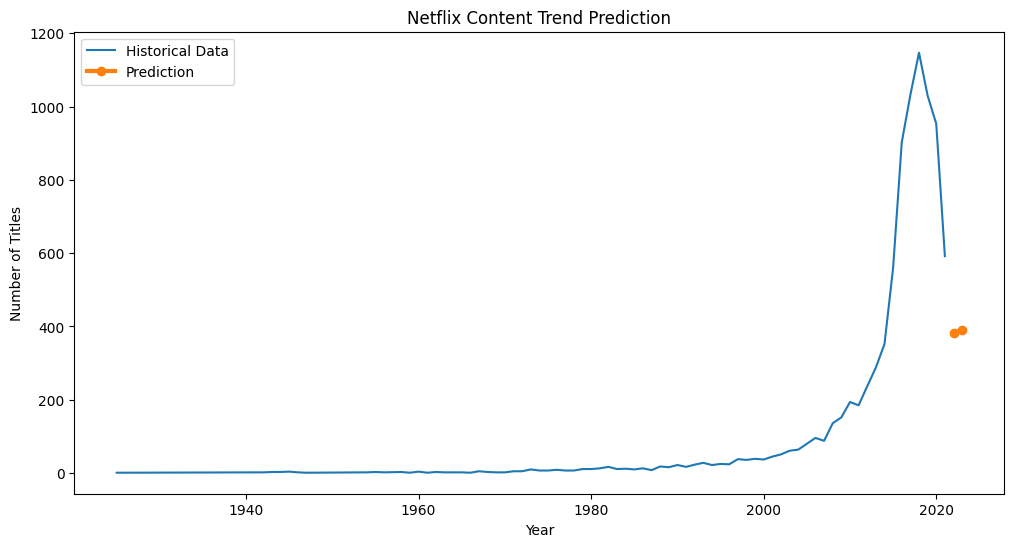

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_content['release_year'],
    yearly_content['count'],
    label='Historical Data'
)

plt.plot(
    future_years['release_year'],
    future_years['predicted_titles'],
    marker='o',
    linewidth=3,
    label='Prediction'
)

plt.title('Netflix Content Trend Prediction')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.legend()

plt.show()

In [30]:
print("Future Predictions:\n")

for _, row in future_years.iterrows():
    print(
        f"Year {int(row['release_year'])}: "
        f"{int(row['predicted_titles'])} titles"
    )

Future Predictions:

Year 2022: 383 titles
Year 2023: 390 titles


In [31]:
findings = pd.DataFrame({
    "Metric": [
        "Top Country",
        "Top Genre",
        "Latest Release Year",
        "Movie Percentage",
        "TV Show Percentage"
    ],
    "Value": [
        top_countries.index[0],
        top_genres.index[0],
        df['release_year'].max(),
        round((df['type']=='Movie').mean()*100,2),
        round((df['type']=='TV Show').mean()*100,2)
    ]
})

findings

,Metric,Value
0,Top Country,United States
1,Top Genre,International Movies
2,Latest Release Year,2021
3,Movie Percentage,69.62
4,TV Show Percentage,30.38


In [32]:
plt.savefig(
    "movie_vs_tvshow.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig("genre_analysis.png")
plt.savefig("release_trend.png")
plt.savefig("country_heatmap.png")

<Figure size 640x480 with 0 Axes>